# Chapter 12 — Text Mining

**Course 888102 — International College of Digital Innovation, Chiang Mai University**

This notebook is the **complete chapter**. Everything is here -- every definition,
every table, every worked example -- plus runnable code for all of it and step-by-step explanations of the
Python. You can follow the whole chapter from this notebook alone; the slides are a condensed version of the
same material, useful for review.

This notebook covers:

- everyday **Natural Language Processing (NLP)** applications: spam detection, voice search, machine
  translation, chatbots -- and why none of them can be written as a simple set of hand-coded rules
- what **text mining** is, and how it turns unstructured text into structured data
- **sentiment analysis**, its three implementation approaches (rules-based, automatic, hybrid), and its four
  common types: Standard, Fine-grained, Emotion Detection, and Aspect-Based
- **how sentiment analysis works**: a full rules-based pipeline, built from scratch and reproducing the
  worked examples exactly
- a recurring blind spot -- **negation** -- that trips up every simple lexicon, seen twice from two angles
- a **glossary** of every term introduced, and the sources behind each example

No specialized NLP library needed -- just plain Python string processing and pandas, so every step stays
visible.

### 🎯 Learning objectives

By the end of this chapter you should be able to:

1. **Understand the concepts** -- explain what NLP, text mining, and sentiment analysis are, and how the
   three relate: NLP is the underlying technology, text mining is the general task of structuring free text,
   and sentiment analysis is one specific text-mining task.
2. **Apply the tools** -- build a rules-based sentiment classifier by hand: tokenize a sentence, strip stop
   words and punctuation, look words up in a lexicon, and aggregate the result into one label. Recognize
   which of the four sentiment-analysis types (SSA, fine-grained, emotion detection, ABSA) a given problem
   calls for.
3. **Communicate results** -- explain, to someone with no coding background, what a sentiment classifier
   found and *why* it might be wrong -- in particular, why a word-counting lexicon cannot detect negation.

### 🗺️ How this notebook is organized

The material is grouped into two parts. Here is where each one lives in this notebook:

| Part | What it asks | Notebook sections |
|---|---|---|
| **1 — NLP in everyday life** | Where does natural language processing already run, and what is text mining? | §1 and §2 |
| **2 — Sentiment analysis** | How do you detect sentiment in text, and what are the different ways of doing it? | §3, §4, and §5 |

§6 is the summary, the glossary, and the sources. §7 is the graded homework.

**How to work through it:** read each section's explanation, run the code cell under it, then read the
"Interpretation" note that follows -- that note tells you what the output you just produced actually means.
The **✏️ Try it** boxes are small challenges; they are not graded, but doing them is the fastest way to find
out whether you really understood the section. The graded work is §7.

### 🆕 Continuing from Chapters 9-11

No prior coding background is assumed, same as the earlier chapters — see Chapter 9's "New to Python? Start
here" cell for the basics (cells, variables, running code) if you haven't seen it yet. This chapter works
mostly with **text** (strings) instead of numbers, so most of the **🐍 Python basics** cells below cover
string-processing tools that haven't come up in Chapters 9-11.

In [1]:
# Import the libraries (run this cell first — everything below depends on it!)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string

plt.rcParams["figure.dpi"] = 100
rng = np.random.default_rng(888102)  # fixed seed so every student gets identical numbers

## 1. Natural Language Processing (NLP) in everyday life

**In plain words:** human language is messy -- full of slang, typos, and ambiguity. **NLP** is the set of
techniques that let software make sense of it anyway: a machine learning technology that gives computers the
ability to interpret, manipulate, and comprehend human language.

**This is the foundation the rest of the chapter builds on:** text mining and sentiment analysis, covered next, are both built on top
of NLP techniques.

You already interact with NLP constantly. None of the four products below are "programmed" in the
traditional sense -- each one learned its behavior from mountains of past data, and none of them could be
written as a simple list of hand-coded if/else rules:

| Application | What NLP is doing there | Why rules-by-hand would not work |
|---|---|---|
| **Spam detection** | A classifier looks at incoming email for specific criteria and routes it to your inbox or spam folder. | Spammers constantly change their wording to dodge fixed rules -- the filter has to keep learning from new examples, not just match a static keyword list. |
| **Voice search** | Links speech recognition to NLP and AI processing systems (Google Assistant, Siri). | Every person's accent, pace, and microphone are different -- the mapping from sound to words is learned from enormous amounts of recorded speech. |
| **Machine translation** | Automatically translates content from a source language to a target language (Google Translate). | Word-for-word substitution produces nonsense -- grammar, idiom, and word order differ between every pair of languages. |
| **Chatbots** | Use AI and NLP to understand customer questions and automate responses, simulating human conversation. | The same question can be phrased in unlimited ways -- no fixed list of exact-match rules could cover them all. |

**The common thread:** take the data away and there is nothing left to learn from, and no product.

**🐍 Python basics — strings, `.lower()`, and the `in` operator**

- A Python **string** is text wrapped in quotes, e.g. `"free"`. `email_text.lower()` returns a new copy of
  the string with every letter lowercased — used so `"FREE"`, `"Free"`, and `"free"` all match the same way.
- `word in text_lower` checks whether `word` appears **anywhere inside** `text_lower` as a substring —
  `"free" in "your free prize"` is `True`.
- `[word for word in spam_keywords if word in text_lower]` is a list comprehension (seen in Chapter 9) that
  keeps only the keywords that actually appear in this particular email.
- `("SPAM" if hits else "NOT SPAM"), hits` returns **two values at once** — a function can `return` a
  comma-separated group of values, which the caller can unpack, e.g. `label, hits = classify_spam(email)`.
  `"SPAM" if hits else "NOT SPAM"` is a compact **conditional expression**: "SPAM" if `hits` is non-empty
  (non-empty lists count as `True`), otherwise "NOT SPAM."

### 1.1 A tiny spam filter, by hand

A spam filter looks for specific criteria -- the simplest version just checks for known "spammy" keywords.

**Spam keywords:** "free", "winner", "click", "urgent", "prize", "act now"
**Rule:** if any keyword appears in the email text, label it SPAM.

| Email | Label | Matched keywords |
|---|---|---|
| "Here is the agenda for tomorrow's meeting." | NOT SPAM | -- |
| "WINNER! Click here to claim your FREE prize!" | SPAM | winner, prize, free, click |
| "Reminder: your invoice is due end of month." | NOT SPAM | -- |

The code below reproduces exactly this rule on three emails (worded slightly differently, same idea):

In [2]:
# A tiny rule-based spam classifier
spam_keywords = {"free", "winner", "click", "urgent", "prize", "act now"}

def classify_spam(email_text):
    text_lower = email_text.lower()
    hits = [word for word in spam_keywords if word in text_lower]
    return ("SPAM" if hits else "NOT SPAM"), hits

emails = [
    "Hi team, here is the agenda for tomorrow's meeting.",
    "CONGRATULATIONS! You are a WINNER! Click here to claim your FREE prize now!",
    "Reminder: your invoice is due at the end of the month.",
]

for email in emails:
    label, hits = classify_spam(email)
    print(f"[{label}] '{email}'  (matched keywords: {hits})")

[NOT SPAM] 'Hi team, here is the agenda for tomorrow's meeting.'  (matched keywords: [])
[SPAM] 'CONGRATULATIONS! You are a WINNER! Click here to claim your FREE prize now!'  (matched keywords: ['prize', 'click', 'free', 'winner'])
[NOT SPAM] 'Reminder: your invoice is due at the end of the month.'  (matched keywords: [])


**Interpretation:** this is the "CLASSIFIER" box of a spam-detection pipeline,
just made explicit — a real spam filter uses thousands of signals (not just keywords), but the core idea is
the same: look for specific criteria, then route the message to the inbox or the spam folder.

## 2. Text mining

**Text mining** is the process of transforming unstructured text into structured data for easy analysis.
Three stages turn a pile of free text into something you can count, filter, and chart:

| Stage | What it is |
|---|---|
| **Unstructured text** | Free-form sentences, reviews, emails -- no rows, no columns, no fixed fields. |
| **Text mining** | Uses NLP to let machines understand and process human language automatically. |
| **Structured data** | A table of labels, scores, and counts -- ready for the analysis tools from earlier chapters. |

The spam classifier above is already a tiny example: it took unstructured email text in and produced a
structured `(label, matched_keywords)` pair out. Everything from here on is a more sophisticated version of
that same idea.

### 2.1 From sentences to a table — the bag of words

Text mining is defined as *"transforming unstructured text into structured data for easy
analysis."* That transformation deserves to be done rather than described, because the result is the bridge
between this chapter and every earlier one: **once text becomes a table of numbers, every tool from Chapters
6 to 11 applies to it.**

The simplest such transformation is the **bag of words**: build a vocabulary of every word that appears, then
count how many times each document uses each word. It is called a *bag* because word order is thrown away —
"dog bites man" and "man bites dog" produce identical rows.

**The representation, written out.** First list every distinct word across all the documents — that list is the
**vocabulary** $V$. Then each document becomes a row of counts, one column per vocabulary word:

$$\mathbf{d} = \left(\text{count of word 1},\; \text{count of word 2},\; \dots,\; \text{count of the last word}\right)$$

Stack one row per document and you have the **document-term matrix**: an ordinary table of numbers.

> **Worked example — three tiny reviews.**
>
> $d_1$: "the food is good" $d_2$: "the food is bad" $d_3$: "the service is good"
>
> **The vocabulary** (every distinct word, in order of first appearance):
> *the, food, is, good, bad, service* — six words, so every document becomes six numbers.
>
> | | the | food | is | good | bad | service |
> |---|---|---|---|---|---|---|
> | $d_1$ | 1 | 1 | 1 | 1 | 0 | 0 |
> | $d_2$ | 1 | 1 | 1 | 0 | 1 | 0 |
> | $d_3$ | 1 | 0 | 1 | 1 | 0 | 1 |
>
> **That table is the whole trick of this chapter.** Three sentences went in; a numeric table came out. Every
> method from Chapters 6 to 11 — k-means, PCA, naive Bayes, decision trees — works on tables like this one, and
> none of them needs to know the rows were ever words.
>
> Notice what was thrown away: *order*. "dog bites man" and "man bites dog" produce identical rows. That is why it
> is called a **bag** of words — as if you tipped the sentence into a bag and shook it.

**Two things to expect from real ones.** A document-term matrix is **wide** — a few thousand reviews easily produce
tens of thousands of distinct words, so there are usually far more columns than rows. And it is **sparse**: any one
review uses a tiny handful of the vocabulary, so almost every entry is $0$. In our toy table 5 of the 18 entries
are already zero; on real data it is often above 99%.

In [3]:
reviews = [
    "The noodles were delicious and the broth was rich",
    "Terrible service and the noodles were cold",
    "Delicious broth, delicious noodles, wonderful service",
    "The service was slow but the food was good",
    "Cold food, slow service, terrible experience",
]

def tokenize(text):
    cleaned = text.lower()
    for mark in string.punctuation:
        cleaned = cleaned.replace(mark, " ")
    return [word for word in cleaned.split() if word]

tokenized = [tokenize(review) for review in reviews]
vocabulary = sorted({word for document in tokenized for word in document})

print(f"{len(reviews)} reviews -> {len(vocabulary)} distinct words in the vocabulary\n")
print(vocabulary)

5 reviews -> 17 distinct words in the vocabulary

['and', 'broth', 'but', 'cold', 'delicious', 'experience', 'food', 'good', 'noodles', 'rich', 'service', 'slow', 'terrible', 'the', 'was', 'were', 'wonderful']


In [4]:
# The document-term matrix: one row per document, one column per vocabulary word.
counts = pd.DataFrame(
    [[document.count(word) for word in vocabulary] for document in tokenized],
    columns=vocabulary,
    index=[f"review {i+1}" for i in range(len(reviews))],
)

print(f"Shape: {counts.shape}  ({counts.shape[0]} documents x {counts.shape[1]} terms)")
print(f"Non-zero cells: {(counts > 0).sum().sum()} of {counts.size} "
      f"({(counts > 0).sum().sum() / counts.size:.0%}) — mostly zeros, as always with text\n")
counts

Shape: (5, 17)  (5 documents x 17 terms)
Non-zero cells: 33 of 85 (39%) — mostly zeros, as always with text



,and,broth,but,cold,delicious,experience,food,good,noodles,rich,service,slow,terrible,the,was,were,wonderful
review 1,1,1,0,0,1,0,0,0,1,1,0,0,0,2,1,1,0
review 2,1,0,0,1,0,0,0,0,1,0,1,0,1,1,0,1,0
review 3,0,1,0,0,2,0,0,0,1,0,1,0,0,0,0,0,1
review 4,0,0,1,0,0,0,1,1,0,0,1,1,0,2,2,0,0
review 5,0,0,0,1,0,1,1,0,0,0,1,1,1,0,0,0,0


**Interpretation:** that table is structured data. It has rows (observations) and columns (variables) exactly
as Chapter 2 defined them, and every technique from the rest of the course now applies — you can cluster the
rows, classify them, reduce their dimensions, or compute distances between them.

Two properties of text data show up immediately and matter enormously in practice:

- **It is sparse.** Most cells are zero, because most reviews use only a handful of the vocabulary. With
  50,000 documents and 30,000 distinct words, over 99.9% of the matrix is zeros — which is why real text
  pipelines use sparse storage rather than a dense table.
- **It is wide.** The vocabulary grows with every new document, so a text dataset can easily have more columns
  than rows. That is exactly the high-dimensionality problem from Chapter 11.

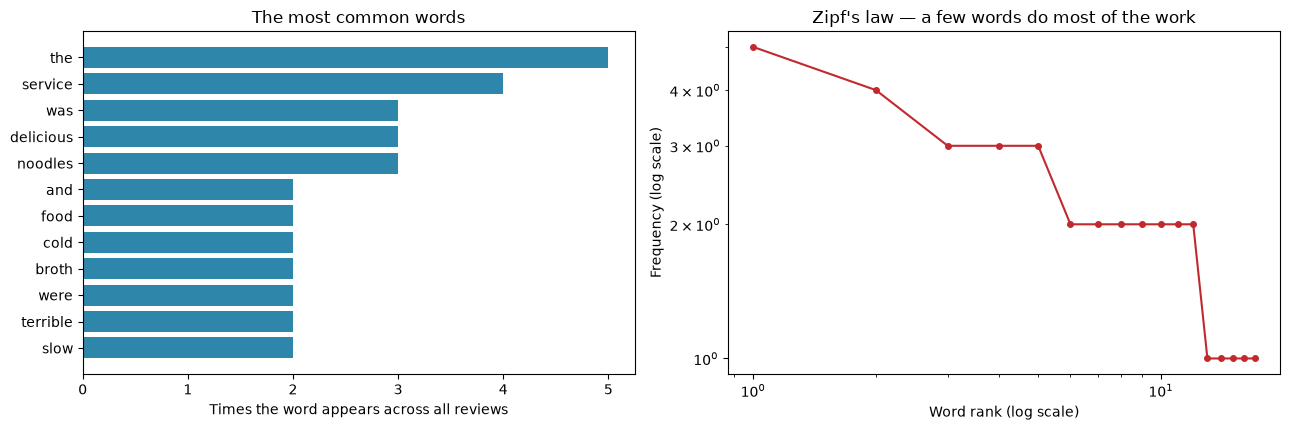

Most frequent words: ['the', 'service', 'was', 'delicious', 'noodles']
Words appearing exactly once: 5 of 17


In [5]:
# Which words dominate? A frequency table, and the shape it always has.
total_counts = counts.sum().sort_values(ascending=False)

fig, (ax_bar, ax_zipf) = plt.subplots(1, 2, figsize=(13, 4.4))

top = total_counts.head(12)
ax_bar.barh(top.index[::-1], top.values[::-1], color="#2E86AB")
ax_bar.set_xlabel("Times the word appears across all reviews")
ax_bar.set_title("The most common words")

ranks = np.arange(1, len(total_counts) + 1)
ax_zipf.plot(ranks, total_counts.values, marker="o", markersize=4, color="#C1292E")
ax_zipf.set_xscale("log")
ax_zipf.set_yscale("log")
ax_zipf.set_xlabel("Word rank (log scale)")
ax_zipf.set_ylabel("Frequency (log scale)")
ax_zipf.set_title("Zipf's law — a few words do most of the work")

plt.tight_layout()
plt.show()

print("Most frequent words:", list(total_counts.head(5).index))
print("Words appearing exactly once:", (total_counts == 1).sum(), f"of {len(total_counts)}")

**Interpretation:** the most frequent words are `the`, `and`, `was` — words that appear in almost every
document and tell you nothing about what any of them is *about*. That is a general property of language known
as **Zipf's law**: word frequency falls off roughly as one over its rank, so a tiny number of words dominate
every corpus and a long tail appears only once or twice.

This creates the central problem of the bag of words: **the most frequent words are the least informative.**
Two fixes, in order of sophistication:

1. **Stop-word removal** — delete a fixed list of known uninformative words. Crude but effective.
2. **TF-IDF weighting** — down-weight words that appear in *many documents*, automatically. Next section.

### 2.2 TF-IDF — weighting words by how much they distinguish

A word is useful for describing a document when it appears **often in that document** and **rarely in the
others**. TF-IDF is that sentence, written as arithmetic:

$$\text{tf-idf}(t, d) = \underbrace{\text{tf}(t, d)}_{\text{how often in this document}} \times \underbrace{\log\frac{N}{\text{df}(t)}}_{\text{how rare across all documents}}$$

where `df(t)` is the number of documents containing the term and N is the total number of documents.

**Each half, separately.** The **term frequency** divides by the document's length, so a long review does not beat
a short one just by containing more words:

$$\text{tf}(t, d) = \frac{\text{how many times } t \text{ appears in } d}{\text{total words in } d}$$

The **inverse document frequency** turns rarity into importance. Writing $N$ for the number of documents and
$\text{df}(t)$ for how many of them contain $t$ at least once:

$$\text{idf}(t) = \log \frac{N}{\text{df}(t)}$$

**Reading the idf.** If a word is in every document, $N/\text{df} = 1$ and $\log 1 = 0$ — the word gets **zero**
weight. If a word is in only one document out of many, the fraction is large and so is the weight. The logarithm is
there to stop that growing absurdly: without it, a word in 1 document out of 10,000 would count 10,000 times more
than a common one, which is far too extreme a verdict. (We use the natural logarithm here; the base changes the
numbers slightly but never the ordering.)

$$\text{tf-idf}(t,d) = \text{tf}(t,d) \times \text{idf}(t)$$

> **Worked example — the same three reviews.** $N = 3$ documents.
>
> **Step 1 — count the documents each word appears in, and take its idf.**
>
> | Word | Appears in | $\text{df}$ | $\text{idf} = \ln(3/\text{df})$ |
> |---|---|---|---|
> | the | $d_1, d_2, d_3$ | 3 | $\ln(3/3) = \ln 1 = \mathbf{0}$ |
> | is | $d_1, d_2, d_3$ | 3 | $\ln 1 = \mathbf{0}$ |
> | food | $d_1, d_2$ | 2 | $\ln 1.5 = 0.405$ |
> | good | $d_1, d_3$ | 2 | $\ln 1.5 = 0.405$ |
> | bad | $d_2$ | 1 | $\ln 3 = \mathbf{1.099}$ |
> | service | $d_3$ | 1 | $\ln 3 = \mathbf{1.099}$ |
>
> **Step 2 — weights for $d_2$ ("the food is bad"), which has 4 words**, so every tf is $1/4 = 0.25$:
>
> | Word | $\text{tf}$ | $\times$ | $\text{idf}$ | $=$ tf-idf |
> |---|---|---|---|---|
> | the | $0.25$ | | $0$ | $\mathbf{0.000}$ |
> | is | $0.25$ | | $0$ | $\mathbf{0.000}$ |
> | food | $0.25$ | | $0.405$ | $0.101$ |
> | bad | $0.25$ | | $1.099$ | $\mathbf{0.275}$ |
>
> **Look at what happened without anybody writing a stopword list.** All four words appear equally often in $d_2$,
> yet "the" and "is" scored exactly **zero** — they are in every document, so they distinguish nothing. "bad"
> scored highest, because it is the one word unique to this review. **TF-IDF worked out which words matter by
> arithmetic alone.** That is the entire idea.

**Comparing two documents.** Once documents are rows of numbers, their similarity is the angle between them:

$$\cos(\mathbf{d}_1, \mathbf{d}_2) = \frac{\mathbf{d}_1 \cdot \mathbf{d}_2}{\lVert \mathbf{d}_1 \rVert \, \lVert \mathbf{d}_2 \rVert}$$

> **Worked example — how alike are $d_1$ and $d_3$?** Using the raw count rows from the table above:
> $\mathbf{d}_1 = (1,1,1,1,0,0)$ and $\mathbf{d}_3 = (1,0,1,1,0,1)$.
>
> **Top** — multiply matching positions and add: $(1)(1) + (1)(0) + (1)(1) + (1)(1) + 0 + (0)(1) = \mathbf{3}$.
> They share three words: *the*, *is*, *good*.
>
> **Bottom** — each row's length: $\lVert \mathbf{d}_1 \rVert = \sqrt{1+1+1+1} = 2$ and
> $\lVert \mathbf{d}_3 \rVert = \sqrt{1+1+1+1} = 2$, so the product is $4$.
>
> **$\cos = 3/4 = \mathbf{0.75}$** — the two reviews are 75% alike in direction.
>
> Dividing by both lengths is what makes this right for text: it removes document length from the comparison
> entirely, so a two-line review and a two-page review about the same restaurant still score as similar. The result
> always sits between $0$ (nothing in common) and $1$ (identical direction).

In [6]:
n_documents = len(tokenized)

# Term frequency: the share of this document made up of each term.
term_frequency = counts.div(counts.sum(axis=1), axis=0)

# Document frequency, and its inverse.
document_frequency = (counts > 0).sum()
inverse_document_frequency = np.log(n_documents / document_frequency)

tfidf = term_frequency * inverse_document_frequency

comparison = pd.DataFrame({
    "appears in N docs": document_frequency,
    "IDF weight": inverse_document_frequency.round(2),
}).sort_values("appears in N docs", ascending=False)

print("Common words get a LOW weight:\n")
print(comparison.head(6).to_string())
print("\n...and rare, distinctive words get the highest weight:\n")
print(comparison.tail(6).to_string())

print(f"\nThe most widespread word here appears in {document_frequency.max()} of {n_documents} reviews,")
print(f"so the smallest IDF is {inverse_document_frequency.min():.2f} — low, but not zero.")
print(f"A word appearing in ALL {n_documents} would score log({n_documents}/{n_documents}) = "
      f"{np.log(n_documents/n_documents):.2f} exactly, and vanish from every document.")
print("With five reviews nothing is quite that universal; with five thousand, 'the' would be.")

Common words get a LOW weight:

         appears in N docs  IDF weight
service                  4        0.22
the                      3        0.51
noodles                  3        0.51
and                      2        0.92
broth                    2        0.92
food                     2        0.92

...and rare, distinctive words get the highest weight:

            appears in N docs  IDF weight
slow                        2        0.92
but                         1        1.61
good                        1        1.61
experience                  1        1.61
rich                        1        1.61
wonderful                   1        1.61

The most widespread word here appears in 4 of 5 reviews,
so the smallest IDF is 0.22 — low, but not zero.
A word appearing in ALL 5 would score log(5/5) = 0.00 exactly, and vanish from every document.
With five reviews nothing is quite that universal; with five thousand, 'the' would be.


Top TF-IDF terms per review — a one-line summary of what each is about:

  review 1: rich (0.179), the (0.114), and (0.102)
  review 2: and (0.131), cold (0.131), terrible (0.131)
  review 3: delicious (0.305), wonderful (0.268), broth (0.153)
  review 4: was (0.204), good (0.179), but (0.179)
  review 5: experience (0.268), slow (0.153), cold (0.153)


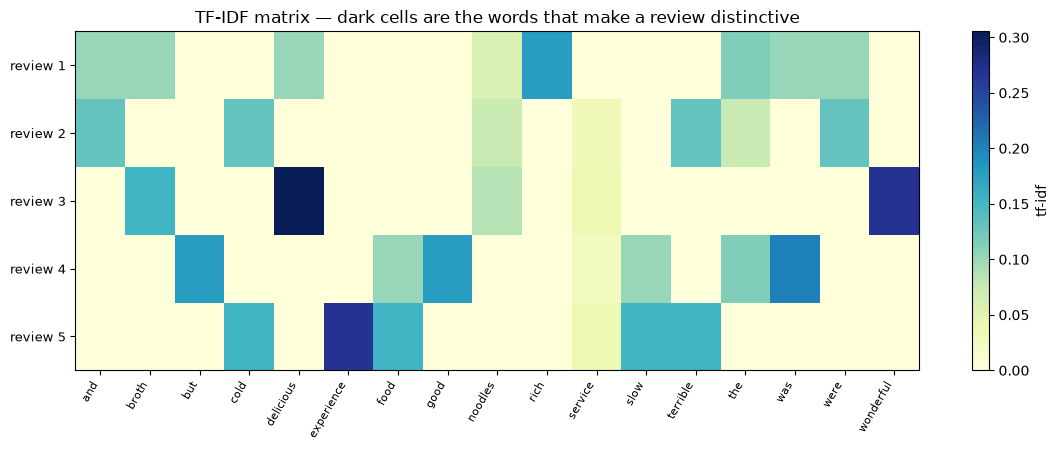

In [7]:
# What does each review look like once weighted?
print("Top TF-IDF terms per review — a one-line summary of what each is about:\n")
for name, row in tfidf.iterrows():
    top_terms = row.sort_values(ascending=False).head(3)
    terms = ", ".join(f"{term} ({value:.3f})" for term, value in top_terms.items() if value > 0)
    print(f"  {name}: {terms}")

fig, ax = plt.subplots(figsize=(11.5, 4.6))
show = tfidf[[c for c in tfidf.columns if tfidf[c].max() > 0]]
image = ax.imshow(show.values, cmap="YlGnBu", aspect="auto")
ax.set_xticks(range(show.shape[1]), show.columns, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(show.shape[0]), show.index, fontsize=9)
ax.set_title("TF-IDF matrix — dark cells are the words that make a review distinctive")
ax.grid(False)
fig.colorbar(image, ax=ax, label="tf-idf")
plt.tight_layout()
plt.show()

**Interpretation:** `the` appears in every review, so its IDF is exactly `log(5/5) = 0` and its weight becomes
zero in every document. **TF-IDF removes stop words without needing a stop-word list** — it discovers which
words are uninformative from the data itself, which also means it adapts to the domain. (In a corpus of legal
documents, "court" is a stop word; in a corpus of restaurant reviews it is not.)

The per-review top terms are already doing useful work — `delicious` and `wonderful` head review 3,
`experience`, `slow`, and `cold` head review 5 — and nobody wrote those summaries; they fell out of the
weighting.

But read the list honestly: `the` and `and` still make the top three for reviews 1 and 2. **Five documents is
not enough for IDF to do its job.** With only five, `the` appears in three of them and keeps a middling
weight. Across five thousand reviews it would appear in nearly all of them, its IDF would collapse toward
zero, and it would disappear on its own. TF-IDF is a statistical effect, and statistics need volume.

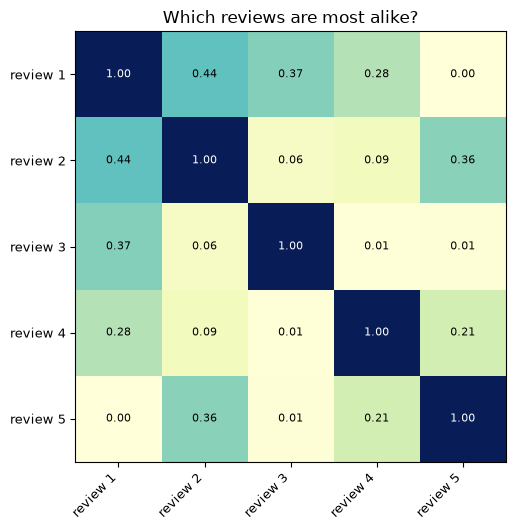

review 1: The noodles were delicious and the broth was rich
review 2: Terrible service and the noodles were cold
review 3: Delicious broth, delicious noodles, wonderful service
review 4: The service was slow but the food was good
review 5: Cold food, slow service, terrible experience


In [8]:
# Now that documents are vectors, they can be compared — exactly as in Chapter 1's recommender.
def cosine_similarity(a, b):
    denominator = np.linalg.norm(a) * np.linalg.norm(b)
    return float(a @ b / denominator) if denominator else 0.0

matrix = tfidf.to_numpy()
similarity = pd.DataFrame(
    [[cosine_similarity(matrix[i], matrix[j]) for j in range(len(matrix))]
     for i in range(len(matrix))],
    index=tfidf.index, columns=tfidf.index,
).round(3)

fig, ax = plt.subplots(figsize=(6.4, 5.4))
image = ax.imshow(similarity.values, cmap="YlGnBu", vmin=0, vmax=1)
ax.set_xticks(range(len(similarity)), similarity.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(similarity)), similarity.index, fontsize=9)
for i in range(len(similarity)):
    for j in range(len(similarity)):
        value = similarity.values[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8,
                color="white" if value > 0.55 else "black")
ax.set_title("Which reviews are most alike?")
ax.grid(False)
plt.tight_layout()
plt.show()

for i, text in enumerate(reviews):
    print(f"review {i+1}: {text}")

**Interpretation:** reviews 1 and 3 (both about delicious noodles and broth) score highest against each other,
and reviews 2 and 5 (both complaints about cold food and terrible service) pair up as well. **Nothing told the
computer which reviews were positive.** The grouping emerged from shared vocabulary alone.

This is exactly the collaborative-filtering machinery from Chapter 1, applied to documents instead of users —
and it is the basis of "related articles," plagiarism detection, and search engines. Feed that similarity
matrix to the clustering from Chapter 11 and you have **topic discovery**: documents grouped by subject, with
nobody having tagged a subject.

## 3. Sentiment analysis

**Sentiment analysis** is the process of detecting positive or negative sentiment in text. Businesses use it
to detect sentiment in social data, gauge brand reputation, and understand customers -- at a scale no human
team could read manually.

## 4. How sentiment analysis works — a rules-based pipeline

Sentiment analysis uses NLP methods and algorithms, falling into three broad approaches:

| Approach | What it is |
|---|---|
| **Rules-based systems** | A set of manually crafted rules -- a dictionary of words mapped to sentiment labels. |
| **Automatic systems** | Rely on machine learning techniques that learn patterns from labeled data. |
| **Hybrid systems** | Combine both rule-based and automatic approaches for the best of each. |

This chapter builds a **rules-based system** by hand, because it is the only one of the three you can trace
completely, line by line, without training any model. Example sentence: *"Sam is a great guy."*

| Step | What happens |
|---|---|
| **1. Tokenize** | Split into tokens: Sam, is, a, great, guy, . |
| **2. Preprocess** | Drop stop words and punctuation: Sam, great, guy |
| **3. Run lexicon** | Look up each word: great → positive |
| **4. Aggregate** | Overall sentiment: positive |

The positive label comes entirely from one word, "great," found in the lexicon -- notice that "Sam" and
"guy" contribute nothing: they are not in the lexicon, so they default to neutral and get ignored once the
overall label is decided. **A rules-based system only ever knows what its dictionary tells it** -- keep that
in mind through the rest of this section.

**🐍 Python basics — `.replace()` and `.split()`**

- `sentence.replace(".", " .")` returns a new string with every `.` replaced by ` .` (a space then a period)
  — this pads punctuation with a space *before* splitting, so the period ends up as its own token instead of
  stuck to the last word (`"guy."` would otherwise stay glued together).
- `.split()` (no arguments) breaks a string into a list of pieces wherever there's whitespace — `"Sam is a
  great guy ."` becomes `['Sam', 'is', 'a', 'great', 'guy', '.']`. This is **tokenization**: turning raw text
  into a list of individual words/symbols the rest of the pipeline can work with one at a time.

In [9]:
# Step 1: Tokenize -- split the sentence into individual tokens (words and punctuation)
sentence = "Sam is a great guy."
tokens = sentence.replace(".", " .").split()
print("Tokenize:", tokens)

Tokenize: ['Sam', 'is', 'a', 'great', 'guy', '.']


**🐍 Python basics — `string.punctuation` and `continue`**

- `string.punctuation` (from the `import string` at the top of the notebook) is a ready-made string
  containing every common punctuation character: `!"#$%&'()*+,-./:;<=>?@[\]^_\`{|}~`. `tok in
  string.punctuation` checks if a token is *just* punctuation.
- `continue` immediately skips the rest of the current loop iteration and jumps to the next one — here, "if
  this token is punctuation, don't add it to `cleaned`; move straight on to the next token." It's a way to
  filter a list inside an explicit loop, as an alternative to a list comprehension.

In [10]:
# Step 2: Preprocess -- remove stop words (common, low-information words) and punctuation
stop_words = {"is", "a", "the", "an", "of", "to", "and"}

def preprocess(tokens):
    cleaned = []
    for tok in tokens:
        if tok in string.punctuation:
            continue          # drop punctuation
        if tok.lower() in stop_words:
            continue          # drop stop words
        cleaned.append(tok)
    return cleaned

content_words = preprocess(tokens)
print("After removing stop words and punctuation:", content_words)

After removing stop words and punctuation: ['Sam', 'great', 'guy']


**🐍 Python basics — `.get()` with a default, and set comprehensions**

- `lexicon.get(word.lower(), "neutral")` looks up `word` in the `lexicon` dictionary, but instead of crashing
  when the word isn't found (like `lexicon[word]` would), it returns the fallback value `"neutral"`. `.get()`
  with a default is the safe way to look something up that might not exist.
- `{label for label in word_sentiments.values() if label != "neutral"}` is a **set comprehension** — like a
  list comprehension, but building a set (unique values, no duplicates). `.values()` gets just the
  dictionary's values (ignoring the keys). This collects every *non-neutral* sentiment word found.
- `labels_found.pop() if len(labels_found) == 1 else (...)` : `.pop()` on a set removes and returns one
  arbitrary item — safe to use here because the surrounding `if` already confirmed the set has *exactly one*
  item (all found sentiments agreed), so there's nothing ambiguous about which one comes out.

In [11]:
# Step 3: Run a lexicon -- a dictionary mapping words to sentiment labels
lexicon = {"great": "positive", "awful": "negative", "terrible": "negative",
           "love": "positive", "hate": "negative", "amazing": "positive"}

word_sentiments = {word: lexicon.get(word.lower(), "neutral") for word in content_words}
print("Word-level sentiment:", word_sentiments)

# Step 4: Aggregate -- the overall sentiment is whichever label appears (ignoring "neutral")
labels_found = {label for label in word_sentiments.values() if label != "neutral"}
overall = labels_found.pop() if len(labels_found) == 1 else ("mixed" if labels_found else "neutral")
print(f"\nSentiment: {overall}")

Word-level sentiment: {'Sam': 'neutral', 'great': 'positive', 'guy': 'neutral'}

Sentiment: positive


**Interpretation:** every step of the pipeline is here: tokenize -> remove stop words/punctuation
-> look up each remaining word in a lexicon -> aggregate to one final label. "Great" is the only word carrying
sentiment here, so the whole sentence is classified **positive** — as expected.

### 4.1 Normalization — making different spellings of one word into one word

The pipeline so far lowercases, strips punctuation, and drops stop words. Real text needs one more step,
because a bag of words treats `delicious`, `Delicious`, and `deliciously` as three unrelated columns.

| Technique | What it does | `studies` becomes | Cost |
|---|---|---|---|
| **Stemming** | Chops off endings by rule | `studi` | Fast, crude, produces non-words |
| **Lemmatization** | Maps to the dictionary form | `study` | Slower, needs a dictionary, correct |

In [12]:
def crude_stem(word):
    # A miniature Porter-style stemmer: strip the most common English endings.
    for suffix in ("ously", "ingly", "edly", "ing", "ies", "ied", "ily", "ly", "es", "ed", "s"):
        if word.endswith(suffix) and len(word) - len(suffix) >= 3:
            stem = word[: -len(suffix)]
            if suffix in ("ies", "ied"):
                stem += "y"
            return stem
    return word

word_forms = ["delicious", "deliciously", "service", "services", "slow", "slowly",
              "study", "studies", "studied", "studying", "wonderful", "cooked", "cooking"]

table = pd.DataFrame({"original": word_forms, "stemmed": [crude_stem(w) for w in word_forms]})
table["collapsed with"] = table.groupby("stemmed")["original"].transform(
    lambda group: ", ".join(sorted(set(group) )))
print(table.to_string(index=False))

print(f"\n{len(word_forms)} word forms collapse to {table['stemmed'].nunique()} stems.")
print("\nNote 'delicious' -> 'deliciou': a stemmer produces non-words, and does not care.")
print("It only has to be CONSISTENT, so that two forms of one word land in the same column.")

   original   stemmed                    collapsed with
  delicious  deliciou                         delicious
deliciously    delici                       deliciously
    service   service                           service
   services    servic                          services
       slow      slow                      slow, slowly
     slowly      slow                      slow, slowly
      study     study studied, studies, study, studying
    studies     study studied, studies, study, studying
    studied     study studied, studies, study, studying
   studying     study studied, studies, study, studying
  wonderful wonderful                         wonderful
     cooked      cook                   cooked, cooking
    cooking      cook                   cooked, cooking

13 word forms collapse to 8 stems.

Note 'delicious' -> 'deliciou': a stemmer produces non-words, and does not care.
It only has to be CONSISTENT, so that two forms of one word land in the same column.


**Interpretation:** stemming cuts the vocabulary — fewer columns, more counts per column, less sparsity. It is
consistently a bit wrong (`deliciou` is not a word) and that does not matter, because the stem is only ever
used as a column name.

Where it *does* matter is when a stemmer collapses words that should stay apart. Classic English examples are
`universal`, `university`, and `universe` all stemming to `univers`. Lemmatization avoids this by consulting a
dictionary, at the cost of being slower and needing language-specific data.

### 4.2 N-grams — putting a little word order back

The bag of words throws away order, and order sometimes carries the entire meaning. **N-grams** — sequences of
n adjacent words — recover some of it.

**The cost of remembering order.** A document of $L$ words contains

$$L - n + 1$$

n-grams of length $n$ — slide a window of width $n$ along the sentence and count the positions.

> **Worked example.** "the food is not very good" — $L = 6$ words.
>
> **Bigrams ($n=2$):** $6 - 2 + 1 = \mathbf{5}$ of them — *the food, food is, is not, not very, very good*.
> **Trigrams ($n=3$):** $6 - 3 + 1 = \mathbf{4}$ — *the food is, food is not, is not very, not very good*.
>
> And here is the payoff: the bag of words sees *good* and calls this review positive. The bigram **not very** and
> the trigram **not very good** carry the negation that a bag of words destroyed.

**But the columns multiply.** With $\lvert V \rvert$ distinct words there are up to $\lvert V \rvert^{n}$ possible
n-grams:

> **Worked example — a modest 5,000-word vocabulary.**
>
> | | Possible columns |
> |---|---|
> | single words | $5{,}000$ |
> | bigrams | $5{,}000^2 = \mathbf{25\ million}$ |
> | trigrams | $5{,}000^3 = \mathbf{125\ billion}$ |
>
> Only a tiny fraction ever actually occur, but the table still becomes dramatically wider and emptier with each
> step up in $n$. **That is the trade:** bigger $n$ captures more meaning and gives the model less evidence per
> column. It is why bigrams are common, trigrams occasional, and anything longer rare outside very large
> collections — the phrase that would settle a hard case usually appears once in the training data, or never, and
> nothing can be learned from a column that is almost entirely zero.

In [13]:
def ngrams(tokens, n):
    return [" ".join(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]

sentence = tokenize("the food was not good at all")
print(f"Tokens      : {sentence}")
print(f"Bigrams (2) : {ngrams(sentence, 2)}")
print(f"Trigrams (3): {ngrams(sentence, 3)}\n")

positive_words = {"good", "delicious", "great", "wonderful"}
print("A unigram bag of words sees:", [w for w in sentence if w in positive_words],
      "-> looks POSITIVE")
print("A bigram model sees:", [g for g in ngrams(sentence, 2) if "not" in g],
      "-> 'not good' is a single negative feature")

# The cost of n-grams: the vocabulary explodes.
sizes = pd.DataFrame({
    "n": [1, 2, 3],
    "distinct n-grams in our 5 reviews": [
        len({g for d in tokenized for g in ngrams(d, n)}) for n in (1, 2, 3)],
})
print()
print(sizes.to_string(index=False))

Tokens      : ['the', 'food', 'was', 'not', 'good', 'at', 'all']
Bigrams (2) : ['the food', 'food was', 'was not', 'not good', 'good at', 'at all']
Trigrams (3): ['the food was', 'food was not', 'was not good', 'not good at', 'good at all']

A unigram bag of words sees: ['good'] -> looks POSITIVE
A bigram model sees: ['was not', 'not good'] -> 'not good' is a single negative feature

 n  distinct n-grams in our 5 reviews
 1                                 17
 2                                 29
 3                                 26


**Interpretation:** `not good` is a bigram, so a bigram model has a single feature meaning exactly what the
phrase means. A unigram model sees `not` and `good` as unrelated columns and, with a positive lexicon, reaches
the opposite conclusion.

**This is the answer to the negation problem**, and Section 5.1b applies it. The cost is visible in
the last table: bigrams roughly double the vocabulary here and multiply it many times over on real text, which
worsens the sparsity problem from Section 2.1. Most practical systems use unigrams plus bigrams and stop
there.

> ✏️ **Try it:** run the same pipeline on `"The food was truly awful."` What does the pipeline predict,
> and does it match your own reading of the sentence?

## 5. Types of sentiment analysis

Sentiment analysis models differ in how you want the text interpreted. The next four subsections take one
type each, and every one of them builds directly on the same tokenize → preprocess → lexicon → aggregate
pipeline from §4 -- they differ only in what the lexicon and aggregation step produce.

| Type | What it does |
|---|---|
| **Standard (SSA)** | Positive, negative, or neutral -- the most common type. |
| **Fine-grained** | Five levels, like a star rating: very positive to very negative. |
| **Emotion detection** | Detects specific emotions: happiness, anger, frustration. |
| **Aspect-based (ABSA)** | Different sentiment for different aspects of the same review. |

### 5.1 Standard Sentiment Analysis (SSA)

SSA identifies the degree of an opinion and classifies it into **positive**, **negative**, or **neutral**.

| Review | Label |
|---|---|
| "I love this new restaurant" | Positive |
| "I'm not sure if I like the food, I think I like the ambiance" | Neutral (intended) |
| "The food there is awful and is their service" | Negative |

A simple lexicon-based classifier gets the 1st and 3rd examples right -- the 2nd one is trickier, and the
code below shows exactly why.

**🐍 Python basics — chained `.replace()` calls and `all()`**

- `text.lower().replace(".", " .").replace(",", " ,").replace("!", " !").split()` **chains** several method
  calls in a row — each one runs on the result of the previous one, left to right: lowercase, then pad out
  periods, then commas, then exclamation marks, then finally split into tokens. Chaining avoids naming a new
  temporary variable after every single step.
- `all(f == "positive" for f in found)` returns `True` only if **every** item in `found` satisfies the
  condition (all are `"positive"`); if even one isn't, it returns `False`. It's a compact way to ask "are
  they *all* the same?" without writing a loop with a flag variable.

In [14]:
def ssa_classify(text, lexicon):
    tokens = preprocess(text.lower().replace(".", " .").replace(",", " ,").replace("!", " !").split())
    found = [lexicon.get(tok) for tok in tokens if lexicon.get(tok)]
    if not found:
        return "neutral"
    if all(f == "positive" for f in found):
        return "positive"
    if all(f == "negative" for f in found):
        return "negative"
    return "neutral"

ssa_lexicon = {"love": "positive", "like": "positive", "awful": "negative", "great": "positive"}

examples = [
    "I love this new restaurant",
    "I'm not sure if I like the food, I think I like the ambiance",
    "The food there is awful and is their service",
]
for text in examples:
    print(f"'{text}' -> {ssa_classify(text, ssa_lexicon)}")

'I love this new restaurant' -> positive
'I'm not sure if I like the food, I think I like the ambiance' -> positive
'The food there is awful and is their service' -> negative


**Interpretation:** the second sentence contains only positive words in our lexicon ("like" twice), so
our simple aggregator calls it "positive" -- but it should be labeled **neutral**, since "not sure if I like"
is hedged. This is a classic rules-based-system limitation: without understanding negation ("not sure"), a
simple lexicon overcounts positive words. Real systems add negation handling to catch exactly this case.

### 5.2 Where a word-counting lexicon breaks: "not sure if I like it"

> *"I'm not sure if I like the food, I think I like the ambiance"*
> Lexicon sees "like" twice, both positive → classifier says **Positive**.
> A human reads "not sure if I like" as hedged → intended label is **Neutral**.

**The pattern:** a word-counting lexicon has no grasp of sentence structure -- it cannot tell "I like it"
from "I'm not sure if I like it." Real systems add explicit **negation handling** to catch phrases like
"not," "never," and "don't think" before they mislead the word count. Keep this pattern in mind -- it comes
back, harder to spot, in §5.2.

### 5.3 Fine-grained sentiment analysis

Graded sentiment analysis adds more categories, similar to 5-star ratings: **very positive, positive,
neutral, negative, very negative**.

### 5.4 Fixing the negation blind spot

It is easy to identify the problem and stop there. It is worth fixing, because the fix is short and the
technique — **negation scope marking** — is what real lexicon-based systems actually do.

The rule: when a negation word appears, flip the sentiment of the next few words until a clause boundary.

In [15]:
NEGATIONS = {"not", "no", "never", "nt", "cannot", "dont", "doesnt", "isnt", "wasnt", "without"}
CLAUSE_BREAKS = {"but", "however", "although", "though", ",", ".", ";"}

def tokenize_keep_breaks(text):
    # Like tokenize(), but keeps clause punctuation as its own token, because
    # negation scope has to stop somewhere.
    cleaned = text.lower().replace("'", "")
    for mark in ",.;":
        cleaned = cleaned.replace(mark, f" {mark} ")
    for mark in string.punctuation:
        if mark not in ",.;":
            cleaned = cleaned.replace(mark, " ")
    return [word for word in cleaned.split() if word]

def mark_negation(tokens, scope=3):
    marked, remaining = [], 0
    for token in tokens:
        if token in CLAUSE_BREAKS:
            remaining = 0
            marked.append(token)
            continue
        if token in NEGATIONS:
            remaining = scope
            marked.append(token)
            continue
        marked.append(f"NOT_{token}" if remaining > 0 else token)
        remaining = max(0, remaining - 1)
    return marked

def negation_aware_classify(text, lexicon):
    tokens = mark_negation(tokenize_keep_breaks(text), scope=4)
    score = 0
    for token in tokens:
        flipped = token.startswith("NOT_")
        base = token[4:] if flipped else token
        label = lexicon.get(base)
        if label is None:
            continue
        value = 1 if label == "positive" else -1
        score += -value if flipped else value
    return ("positive" if score > 0 else "negative" if score < 0 else "neutral"), score

sentiment_lexicon = {"love": "positive", "like": "positive", "good": "positive",
                     "great": "positive", "delicious": "positive", "sure": "positive",
                     "awful": "negative", "terrible": "negative", "bad": "negative",
                     "dislike": "negative", "cold": "negative", "slow": "negative"}

test_sentences = [
    "I love this new restaurant",
    "I'm not sure if I like the food, I think I like the ambiance",
    "The food there is awful and is their service",
    "The food was not good at all",
    "This is not bad",
]

print(f"{'sentence':<62} {'naive':>10} {'negation-aware':>16}")
for sentence in test_sentences:
    naive = ssa_classify(sentence, sentiment_lexicon)
    aware, score = negation_aware_classify(sentence, sentiment_lexicon)
    print(f"{sentence[:60]:<62} {naive:>10} {aware:>10} ({score:+d})")

sentence                                                            naive   negation-aware
I love this new restaurant                                       positive   positive (+1)
I'm not sure if I like the food, I think I like the ambiance     positive   negative (-1)
The food there is awful and is their service                     negative   negative (-1)
The food was not good at all                                     positive   negative (-1)
This is not bad                                                  negative   positive (+1)


In [16]:
# What the marking actually does to the tokens.
# Where the clause-boundary rule earns its place.
example = "the soup was not good but delicious"
tokens = tokenize_keep_breaks(example)
print(f"Original : {example}")
print(f"Tokens   : {tokens}\n")

print("WITH the boundary rule ('but' stops the negation):")
print(f"  Marked : {mark_negation(tokens, scope=4)}")
print(f"  Result : {negation_aware_classify(example, sentiment_lexicon)}")
print("  -> 'good' is flipped, 'delicious' is not. The halves cancel: a mixed sentence.\n")

saved = set(CLAUSE_BREAKS)
CLAUSE_BREAKS.clear()
print("WITHOUT the boundary rule:")
print(f"  Marked : {mark_negation(tokens, scope=4)}")
print(f"  Result : {negation_aware_classify(example, sentiment_lexicon)}")
print("  -> the negation leaks past 'but' and flips 'delicious' as well,")
print("     dragging a genuinely mixed sentence to negative.")
CLAUSE_BREAKS.update(saved)

Original : the soup was not good but delicious
Tokens   : ['the', 'soup', 'was', 'not', 'good', 'but', 'delicious']

WITH the boundary rule ('but' stops the negation):
  Marked : ['the', 'soup', 'was', 'not', 'NOT_good', 'but', 'delicious']
  Result : ('neutral', 0)
  -> 'good' is flipped, 'delicious' is not. The halves cancel: a mixed sentence.

WITHOUT the boundary rule:
  Marked : ['the', 'soup', 'was', 'not', 'NOT_good', 'NOT_but', 'NOT_delicious']
  Result : ('negative', -2)
  -> the negation leaks past 'but' and flips 'delicious' as well,
     dragging a genuinely mixed sentence to negative.


**Interpretation:** two rows changed, and one did not.

- **"The food was not good at all"** flips from positive to negative. The naive classifier counted `good`; the
  negation-aware one sees `NOT_good`.
- **"This is not bad"** flips from negative to positive — a case a word-counter gets exactly backwards.
- **"I'm not sure if I like the food, I think I like the ambiance"** moves from positive to negative — and
  the intended label is *neutral*, so it is still wrong, just wrong in the other direction.

That third row is worth sitting with, because it shows the limit of the technique rather than its success.
With a scope of four words, the negation flips both `sure` and the first `like` (−2), while the second `like`
contributes +1, netting −1. Shorten the scope and the sentence swings back to positive; lengthen it and it
goes further negative. **The scope parameter does not have a correct value here — it just trades one error for
another.**

Getting this sentence right needs an understanding that *"not sure if I like X"* hedges the whole clause, which
is grammar rather than word counting.

**A heuristic that fixes two cases out of three is a real improvement and not a solution.** That gap is
precisely why the *automatic* approach exists, and Section 5.5 builds one.

The cell below shows the other half of the technique: **scope matters as much as detection.** A negation that
runs to the end of the sentence is nearly as wrong as no negation handling at all.

### 5.5 The automatic approach — learning the lexicon instead of writing it

There are three approaches: **rules-based**, **automatic**, and **hybrid**. Everything above is
rules-based — the dictionary was written by hand, and the system only knows what the dictionary tells it.

An **automatic** system is a supervised classifier from Chapter 10, applied to the document-term matrix from
Section 2.1: show it labeled examples and let it work out which words matter. Naive Bayes is the classic
choice for text.

**The classifier, written out for text.** Chapter 10 gave Bayes' theorem. Applied to a review $d$ made of words
$t_1, \dots, t_L$, choosing between classes $c$ (positive or negative), it says: *pick whichever class makes this
particular review most likely.*

$$\hat{c} = \arg\max_{c} \; \underbrace{P(c)}_{\text{how common this class is}} \times \prod_{i=1}^{L} \underbrace{P(t_i \mid c)}_{\text{how typical each word is of it}}$$

The $\prod$ symbol means "multiply all of these together" — one factor per word in the review. This is the "naive"
part: it treats every word as arriving independently of the others, which for real language is plainly untrue and
works remarkably well anyway.

Each word probability uses Laplace smoothing, exactly as in Chapter 10, because a single unseen word would
otherwise multiply the whole thing to zero:

$$P(t \mid c) = \frac{\text{times } t \text{ appears in class } c \;+\; 1}{\text{total words in class } c \;+\; \lvert V \rvert}$$

> **Worked example — classifying the word "delicious".** Suppose the training reviews give:
>
> - 6 positive reviews and 4 negative, so $P(\text{pos}) = 6/10 = 0.6$ and $P(\text{neg}) = 0.4$
> - "delicious" appears **5 times** among the 20 words of the positive reviews, and **0 times** among the 10 words
>   of the negative reviews
> - the vocabulary holds $\lvert V \rvert = 8$ distinct words
>
> **Step 1 — the two word probabilities, with smoothing.**
> $P(\text{delicious} \mid \text{pos}) = \dfrac{5 + 1}{20 + 8} = \dfrac{6}{28} = \mathbf{0.214}$
> $P(\text{delicious} \mid \text{neg}) = \dfrac{0 + 1}{10 + 8} = \dfrac{1}{18} = \mathbf{0.056}$
>
> Without smoothing the second would have been $0/10 = 0$, and *any* review containing "delicious" would have been
> declared impossible to be negative — however many other negative words it carried.
>
> **Step 2 — score each class.**
> Positive: $0.6 \times 0.214 = \mathbf{0.129}$
> Negative: $0.4 \times 0.056 = \mathbf{0.022}$
>
> $0.129 > 0.022$, so the review is classified **positive** — about 6 times more strongly.

**One practical detail that is not optional.** A real review has hundreds of words, and multiplying hundreds of
numbers each below $1$ produces something so small the computer rounds it to zero — $0.1$ multiplied by itself 400
times is a decimal point followed by 400 zeros. So implementations add **logarithms** instead of multiplying
probabilities, which is safe because $\log$ preserves order: whichever class was winning still wins.

$$\hat{c} = \arg\max_{c} \; \left[ \log P(c) + \sum_{i=1}^{L} \log P(t_i \mid c) \right]$$

> **The same example, in logs.**
> Positive: $\ln(0.6) + \ln(0.214) = -0.511 + (-1.542) = \mathbf{-2.053}$
> Negative: $\ln(0.4) + \ln(0.056) = -0.916 + (-2.890) = \mathbf{-3.806}$
>
> $-2.053$ is the larger (less negative) number, so **positive** wins again — the same verdict, reached by adding
> instead of multiplying, with no risk of underflow.

This also explains how the classifier behaves: each word contributes its own separate term to a running total, so
a review's verdict is just a tally of per-word evidence. That makes it easy to inspect word by word — and just as
blind to negation as the hand-written lexicon above, since "not" is only ever one more word in the sum.

In [17]:
# A small labeled training set of restaurant reviews.
training = [
    ("the noodles were delicious and the broth was rich", "positive"),
    ("wonderful service and amazing food", "positive"),
    ("delicious food, friendly staff, will come back", "positive"),
    ("great value and the soup was excellent", "positive"),
    ("the best noodles in town, absolutely delicious", "positive"),
    ("lovely atmosphere and tasty dishes", "positive"),
    ("terrible service and the noodles were cold", "negative"),
    ("cold food, slow service, terrible experience", "negative"),
    ("awful broth and rude staff", "negative"),
    ("overpriced and the soup was bland", "negative"),
    ("worst meal, dirty tables, slow service", "negative"),
    ("disappointing food and unfriendly staff", "negative"),
]

def train_text_naive_bayes(labeled, alpha=1.0):
    vocabulary = sorted({word for text, _ in labeled for word in tokenize(text)})
    classes = sorted({label for _, label in labeled})
    priors, word_probabilities = {}, {}
    for label in classes:
        documents = [tokenize(text) for text, l in labeled if l == label]
        priors[label] = len(documents) / len(labeled)
        all_words = [word for document in documents for word in document]
        total = len(all_words) + alpha * len(vocabulary)
        for word in vocabulary:
            word_probabilities[(word, label)] = (all_words.count(word) + alpha) / total
    return vocabulary, classes, priors, word_probabilities

vocabulary_nb, classes_nb, priors_nb, likelihood_nb = train_text_naive_bayes(training)
print(f"Trained on {len(training)} reviews, vocabulary of {len(vocabulary_nb)} words.")

def classify_text(text):
    scores = {}
    for label in classes_nb:
        log_score = np.log(priors_nb[label])
        for word in tokenize(text):
            if word in vocabulary_nb:
                log_score += np.log(likelihood_nb[(word, label)])
        scores[label] = log_score
    total = sum(np.exp(v) for v in scores.values())
    return {label: np.exp(v) / total for label, v in scores.items()}

for text in ["the broth was rich and the staff were friendly",
             "bland soup and rude service",
             "the noodles were fine"]:
    probabilities = classify_text(text)
    winner = max(probabilities, key=probabilities.get)
    print(f"\n'{text}'\n  -> {winner}  (P = {probabilities[winner]:.3f})")

Trained on 12 reviews, vocabulary of 43 words.

'the broth was rich and the staff were friendly'
  -> positive  (P = 0.864)

'bland soup and rude service'
  -> negative  (P = 0.916)

'the noodles were fine'
  -> positive  (P = 0.675)


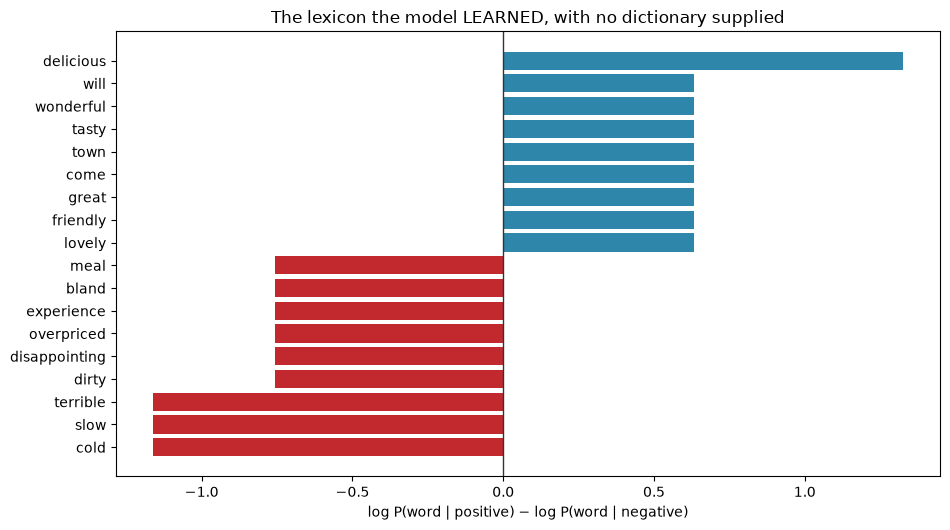

Most positive words: ['delicious', 'will', 'wonderful', 'tasty', 'town']
Most negative words: ['cold', 'slow', 'terrible', 'dirty', 'disappointing']


In [18]:
# Which words did it learn to care about? Nobody supplied a lexicon.
evidence = []
for word in vocabulary_nb:
    ratio = np.log(likelihood_nb[(word, "positive")] / likelihood_nb[(word, "negative")])
    evidence.append((word, ratio))
evidence = pd.DataFrame(evidence, columns=["word", "log ratio"]).sort_values("log ratio")

fig, ax = plt.subplots(figsize=(9.6, 5.4))
extremes = pd.concat([evidence.head(9), evidence.tail(9)])
colors = ["#C1292E" if v < 0 else "#2E86AB" for v in extremes["log ratio"]]
ax.barh(extremes["word"], extremes["log ratio"], color=colors)
ax.axvline(0, color="#333", linewidth=1)
ax.set_xlabel("log P(word | positive) − log P(word | negative)")
ax.set_title("The lexicon the model LEARNED, with no dictionary supplied")
plt.tight_layout()
plt.show()

print("Most positive words:", list(evidence.tail(5)["word"])[::-1])
print("Most negative words:", list(evidence.head(5)["word"]))

**Interpretation:** the model discovered that `delicious`, `wonderful`, and `tasty` signal positive reviews
and `terrible`, `cold`, and `slow` signal negative ones — **without anyone writing a sentiment dictionary.**
That is the whole appeal of the automatic approach.

Now look at the rest of the positive list: `will` and `town` are in there too, with no sentiment whatsoever.
They appear only in positive training reviews ("will come back", "best noodles in town"), so the model has
learned an association that is pure coincidence of a twelve-review sample. **A learned lexicon contains
whatever correlates in the training data**, including things that mean nothing — which is Chapter 3's spurious
correlation, arriving in a new costume.

| | Rules-based | Automatic |
|---|---|---|
| **Needs** | A hand-written lexicon | Labeled training examples |
| **Adapts to a new domain** | Rewrite the dictionary | Retrain on new labels |
| **Handles slang, typos, new words** | Only if you add them | If they appear in training data |
| **Explainable** | ✅ Completely — you wrote the rules | ⚠️ Inspectable, as above, but not authored |
| **Fails when** | Language departs from the dictionary | Training data is small or unrepresentative |

**A hybrid system** uses both: a lexicon for reliable, well-understood cases and a learned model for
everything else. That is what most production sentiment systems actually are.

⚠️ Our training set has twelve reviews. Chapter 9's warning applies in full — this model will do well on
vocabulary it has seen and have nothing useful to say about anything else. Note the third test sentence: "the
noodles were fine" contains no word the model has an opinion about, and the answer it gives is driven almost
entirely by the prior.

| Response | Label |
|---|---|
| "The older interface was much simpler" | Neutral |
| "Awful experience. I would never buy this again!" | Very Negative |
| "I don't think there is anything I really dislike" | Neutral (intended) — "don't think... dislike" is a double negative, the same blind spot as before |

"Awful" and "never" stack two negative signals, correctly landing at Very Negative -- the extra resolution
fine-grained analysis buys over plain positive/negative/neutral.

**🐍 Python basics — a running score, and merging dictionaries with `{**a, **b}`**

- `score` starts at 0 and is nudged up or down as the loop scans each token — a **running total** or
  **accumulator** pattern: a variable declared before the loop, updated inside it, and read after it finishes.
  `intensifier_active` is a boolean flag remembering "did the *previous* token boost intensity?" — it gets
  reset to `False` after every token so the boost only applies to the one word right after "very"/"really".
- `{**fine_lexicon, **fine_lexicon_extra}` **merges** two dictionaries into a new one — `**` unpacks each
  dictionary's key-value pairs into the new `{}`. If the same key appeared in both, the later one (here,
  `fine_lexicon_extra`) would win.

In [19]:
intensity_words = {"very", "really", "truly", "extremely"}

def fine_grained_classify(text, lexicon):
    tokens = text.lower().replace(",", " ,").replace(".", " .").replace("!", " !").split()
    tokens = preprocess(tokens)
    score = 0
    intensifier_active = False
    for tok in tokens:
        if tok in intensity_words:
            intensifier_active = True
            continue
        sentiment = lexicon.get(tok)
        if sentiment == "positive":
            score += 2 if intensifier_active else 1
        elif sentiment == "negative":
            score -= 2 if intensifier_active else 1
        intensifier_active = False
    if score >= 2:
        return "Very Positive"
    if score == 1:
        return "Positive"
    if score == 0:
        return "Neutral"
    if score == -1:
        return "Negative"
    return "Very Negative"

fine_lexicon = {"simpler": "neutral", "awful": "negative", "dislike": "negative", "buy": "neutral"}
fine_lexicon_extra = {"never": "negative"}

reviews = [
    "The older interface was much simpler",
    "Awful experience. I would never buy this product again!",
    "I don't think there is anything I really dislike about the product",
]
combined_lexicon = {**fine_lexicon, **fine_lexicon_extra}
for text in reviews:
    print(f"'{text}' -> {fine_grained_classify(text, combined_lexicon)}")

'The older interface was much simpler' -> Neutral
'Awful experience. I would never buy this product again!' -> Very Negative
'I don't think there is anything I really dislike about the product' -> Very Negative


**Interpretation:** "Awful experience... never buy... again" stacks up two negative signals ("awful"
and "never"), landing it at **Very Negative** — as expected. This is the extra resolution fine-grained
analysis buys you over plain positive/negative/neutral: it can tell "bad" apart from "*really* bad."

Notice the third example: we label *"I don't think there is anything I really dislike about the
product"* as **Neutral**, but our classifier says **Very Negative**. "Don't think there is anything... dislike"
is a double negative -- the same negation blind spot from Section 5.1, just harder to spot. A rules-based
lexicon that only counts individual words, with no grasp of sentence structure, will keep making this exact
mistake.

### 5.6 Emotion detection

Emotion detection identifies specific emotions underlying a text (happiness, anger, frustration), not just
positive/negative polarity. It's more sophisticated than SSA, since the same word can carry different
emotional weight depending on context (e.g. "sick" can mean ill, or, informally, "awesome").

**🐍 Python basics — dictionary lookup inside a list comprehension**

- `[lexicon[tok] for tok in tokens if tok in lexicon]` builds a list of the emotion label for every token
  that *is* a key in `lexicon`, skipping any token that isn't -- combining a membership check (`in`) and a
  lookup (`lexicon[tok]`) in one comprehension.
- `emotions[0] if emotions else "none detected"` takes the first emotion found, or falls back to a default
  string if the list came back empty -- the same "value if condition else fallback" pattern seen in §1's
  spam classifier.

Detection works off a lexicon mapping words to emotions:

| Message | Detected emotion |
|---|---|
| "Hubspot makes my day a lot easier :)" | Happiness |
| "Your customer service is a nightmare! Totally useless!!" | Anger |

The downside: people express feelings differently, and words can flip meaning by context -- "she feels
sick" (negative) versus "that's so sick!" (positive slang). A fixed lexicon has no way to tell those two
apart.

In [20]:
emotion_lexicon = {
    "easier": "happiness", "great": "happiness", "love": "happiness",
    "nightmare": "anger", "useless": "anger", "terrible": "anger",
}

def detect_emotion(text, lexicon):
    tokens = preprocess(text.lower().replace("!", " !").replace(".", " .").split())
    emotions = [lexicon[tok] for tok in tokens if tok in lexicon]
    return emotions[0] if emotions else "none detected"

texts = [
    "Hubspot makes my day a lot easier :)",
    "Your customer service is a nightmare! Totally useless!!",
]
for text in texts:
    print(f"'{text}' -> {detect_emotion(text, emotion_lexicon)}")

'Hubspot makes my day a lot easier :)' -> happiness
'Your customer service is a nightmare! Totally useless!!' -> anger


### 5.7 Aspect-based sentiment analysis (ABSA)

ABSA categorizes text by **aspect** (which part of the product/service is being discussed) and identifies
the sentiment **for each aspect separately** -- useful when one review praises one thing and criticizes
another.

Example sentence: *"The mountain hill hotel was good, but the food was really bad."*

| Clause | Aspect | Sentiment |
|---|---|---|
| "...hotel was good" | Location | Positive |
| "...the food was really bad" | Food | Negative |

An SSA or fine-grained classifier would have to pick one overall label for this whole sentence -- ABSA is
the only type of the four that keeps both signals intact.

**🐍 Python basics — `next()` with a default, and padded formatting**

- `review.split(",")` splits on commas instead of whitespace, breaking the review into clauses. `c.strip()`
  removes any leading/trailing spaces left over from the split.
- `next((aspect_keywords[w] for w in words if w in aspect_keywords), "general")` scans the generator
  expression in parentheses for the **first** matching aspect keyword, and returns `"general"` if none is
  found. `next()` with a default is a tidy way to say "give me the first match, or a fallback if there isn't
  one" without writing a loop with a `break`.
- `f"{aspect:10s}"` is a format spec that **pads** the text with spaces up to 10 characters wide, so the
  printed columns line up neatly regardless of how long each aspect name is.

In [21]:
# The hotel review, split by clause into separate aspects
review = "The mountain hill hotel was good, but the food was really bad"
clauses = [c.strip() for c in review.split(",")]

aspect_lexicon = {"good": "positive", "bad": "negative"}
aspect_keywords = {"hotel": "location", "food": "food"}

for clause in clauses:
    words = clause.lower().split()
    aspect = next((aspect_keywords[w] for w in words if w in aspect_keywords), "general")
    sentiment_words = [aspect_lexicon[w] for w in words if w in aspect_lexicon]
    sentiment = sentiment_words[0] if sentiment_words else "neutral"
    print(f"Clause: '{clause}'  ->  Aspect: {aspect:10s} Sentiment: {sentiment}")

Clause: 'The mountain hill hotel was good'  ->  Aspect: location   Sentiment: positive
Clause: 'but the food was really bad'  ->  Aspect: food       Sentiment: negative


**Interpretation:** a single review produces **two different sentiments** for **two different aspects**
-- positive for location, negative for food. A plain SSA classifier would have to squash this into one
confusing "mixed" label; ABSA keeps the useful detail: *what* was good and *what* wasn't.

---
## 6. Evaluating a text classifier

A sentiment classifier is a classifier, so Chapter 10's evaluation applies unchanged: hold out labeled data,
build a confusion matrix, and look past accuracy.

The four counts and their ratios carry over unchanged:

$$\text{Precision} = \frac{TP}{TP + FP}
\qquad
\text{Recall} = \frac{TP}{TP + FN}
\qquad
F_1 = 2\times\frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

**What text adds is that there are usually more than two classes** — positive/neutral/negative, or a list of
emotions. Precision and recall are then worked out separately for each class and combined afterwards, and there
are two ways to combine them that answer genuinely different questions:

$$F_1^{\text{macro}} = \text{the plain average of each class's } F_1
\qquad\qquad
\text{micro} = \text{pool all the counts first, then compute once}$$

> **Worked example — three sentiment classes, and two very different verdicts.**
>
> | Class | TP | FP | FN | Precision | Recall | $F_1$ |
> |---|---|---|---|---|---|---|
> | Positive (common) | 80 | 10 | 10 | $80/90 = 0.889$ | $80/90 = 0.889$ | $0.889$ |
> | Neutral | 15 | 5 | 5 | $15/20 = 0.750$ | $15/20 = 0.750$ | $0.750$ |
> | Negative (rare) | 1 | 4 | 4 | $1/5 = 0.200$ | $1/5 = 0.200$ | $\mathbf{0.200}$ |
>
> **Macro $F_1$** — average the three class scores, each counting equally:
> $(0.889 + 0.750 + 0.200)/3 = 1.839/3 = \mathbf{0.613}$
>
> **Micro** — pool the counts first: $TP = 80+15+1 = 96$, $FP = 10+5+4 = 19$, $FN = 10+5+4 = 19$.
> Precision $= 96/115 = 0.835$, recall $= 96/115 = 0.835$, so micro $F_1 = \mathbf{0.835}$.
>
> **$0.61$ versus $0.83$ — from one identical set of predictions.** Micro-averaging lets the 80 easy positive
> reviews carry the score, and the negative class, where the model is nearly useless, contributes only 5 of the 115
> documents. Macro-averaging gives that failing class a full third of the vote and reports the problem.
>
> **Which is right depends on what you need.** If you are hunting angry customers, the rare class is the entire
> point and macro is the honest number. If you only care about total documents handled correctly, micro is fair.
> **Quoting the higher one without saying which you used is a well-worn way to oversell a text classifier.**

In [22]:
# A held-out test set the model has never seen.
test_set = [
    ("the soup was excellent and the staff friendly", "positive"),
    ("amazing noodles, will definitely come back", "positive"),
    ("rich broth and lovely service", "positive"),
    ("delicious and great value", "positive"),
    ("cold noodles and slow service", "negative"),
    ("terrible experience, rude staff", "negative"),
    ("bland and overpriced", "negative"),
    ("awful food, dirty tables", "negative"),
]

predictions = [max(classify_text(text), key=classify_text(text).get) for text, _ in test_set]
actual = [label for _, label in test_set]

results = pd.DataFrame({"review": [t for t, _ in test_set],
                        "actual": actual, "predicted": predictions})
results["correct"] = results["actual"] == results["predicted"]
print(f"Test accuracy: {results['correct'].mean():.0%} "
      f"({results['correct'].sum()}/{len(results)})\n")
results

Test accuracy: 100% (8/8)



,review,actual,predicted,correct
0,the soup was excellent and the staff friendly,positive,positive,True
1,"amazing noodles, will definitely come back",positive,positive,True
2,rich broth and lovely service,positive,positive,True
3,delicious and great value,positive,positive,True
4,cold noodles and slow service,negative,negative,True
5,"terrible experience, rude staff",negative,negative,True
6,bland and overpriced,negative,negative,True
7,"awful food, dirty tables",negative,negative,True


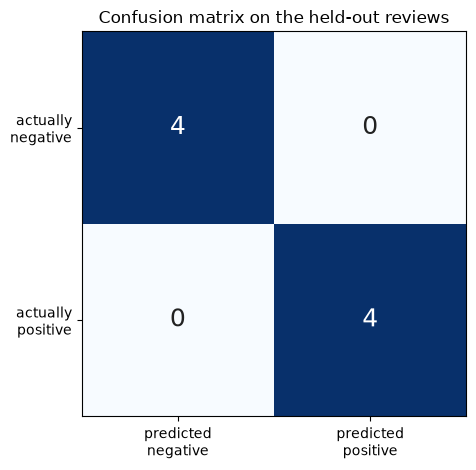

Precision (of reviews called positive, how many were): 100%
Recall    (of positive reviews, how many we caught)  : 100%


In [23]:
labels = ["negative", "positive"]
matrix = np.array([[sum(1 for a, p in zip(actual, predictions) if a == row and p == column)
                    for column in labels] for row in labels])

true_positive = matrix[1, 1]
false_positive = matrix[0, 1]
false_negative = matrix[1, 0]
precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) else np.nan
recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) else np.nan

fig, ax = plt.subplots(figsize=(5.8, 4.8))
image = ax.imshow(matrix, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, matrix[i, j], ha="center", va="center", fontsize=18,
                color="white" if matrix[i, j] > matrix.max() / 2 else "#222")
ax.set_xticks([0, 1], [f"predicted\n{l}" for l in labels])
ax.set_yticks([0, 1], [f"actually\n{l}" for l in labels])
ax.set_title("Confusion matrix on the held-out reviews")
ax.grid(False)
plt.tight_layout()
plt.show()

print(f"Precision (of reviews called positive, how many were): {precision:.0%}")
print(f"Recall    (of positive reviews, how many we caught)  : {recall:.0%}")

**Interpretation:** the model does well on this test set, and you should discount that heavily. Eight test
reviews written in the same style as twelve training reviews is not a serious evaluation — the vocabulary
overlaps almost completely, which is the easiest possible case.

**A realistic evaluation of a sentiment system needs test data that differs from training data** in the ways
real data will: different writers, different vocabulary, sarcasm, typos, mixed languages. Chapter 9's advice
holds — a score measured on data too similar to the training set is an optimistic score.

**And which error costs more depends on the use.** For brand monitoring, a missed complaint (false negative)
matters far more than a miscounted compliment. For automatically publishing testimonials, a false positive is
the expensive one.

---
## 7. Text mining in Thai — why the first step breaks

Everything above assumed `text.split()` finds words. Thai is written **without spaces between words**, so the
very first step of the pipeline fails.

In [24]:
thai_sentence = "อาหารอร่อยมากแต่บริการช้า"      # "the food is very tasty but the service is slow"

print(f"Thai sentence   : {thai_sentence}")
print(f"Naive .split()  : {thai_sentence.split()}")
print(f"  -> {len(thai_sentence.split())} 'token', which is the whole sentence. The pipeline is dead here.\n")

# A dictionary-based segmenter: repeatedly take the longest word that matches.
thai_dictionary = ["อาหาร", "อร่อย", "มาก", "แต่", "บริการ", "ช้า", "ดี", "ไม่", "ราคา", "ถูก", "แพง"]

def segment_thai(text, dictionary):
    words, position = [], 0
    longest = max(len(w) for w in dictionary)
    while position < len(text):
        for size in range(min(longest, len(text) - position), 0, -1):
            candidate = text[position:position + size]
            if candidate in dictionary:
                words.append(candidate)
                position += size
                break
        else:
            words.append(text[position])       # unknown character
            position += 1
    return words

segmented = segment_thai(thai_sentence, thai_dictionary)
print(f"Longest-matching segmentation: {segmented}")
print(f"  -> {len(segmented)} tokens\n")

thai_lexicon = {"อร่อย": "positive", "ดี": "positive", "ถูก": "positive",
                "ช้า": "negative", "แพง": "negative"}
found = [(w, thai_lexicon[w]) for w in segmented if w in thai_lexicon]
print("Sentiment words found:", found)
print("-> Mixed: the food is praised, the service is criticized — an ABSA case.")

Thai sentence   : อาหารอร่อยมากแต่บริการช้า
Naive .split()  : ['อาหารอร่อยมากแต่บริการช้า']
  -> 1 'token', which is the whole sentence. The pipeline is dead here.

Longest-matching segmentation: ['อาหาร', 'อร่อย', 'มาก', 'แต่', 'บริการ', 'ช้า']
  -> 6 tokens

Sentiment words found: [('อร่อย', 'positive'), ('ช้า', 'negative')]
-> Mixed: the food is praised, the service is criticized — an ABSA case.


**Interpretation:** `.split()` returns the entire sentence as one token, and every downstream step — bag of
words, TF-IDF, lexicon lookup — receives nothing usable. **Word segmentation is a required preprocessing step
for Thai, Chinese, Japanese, and Khmer**, and it is a hard problem in its own right rather than a formality.

The longest-matching algorithm above is the classic first approach and it is genuinely fragile: it depends
entirely on the dictionary, and it can segment ambiguously. The standard Thai example is **ตากลม**, which
splits as ตา-กลม ("round eyes") or ตาก-ลม ("air out in the wind") — and only context decides which is meant.

In practice, use a maintained library. **PyThaiNLP** is the standard for Thai:

```python
# pip install pythainlp
from pythainlp import word_tokenize
word_tokenize("อาหารอร่อยมากแต่บริการช้า", engine="newmm")
# -> ['อาหาร', 'อร่อย', 'มาก', 'แต่', 'บริการ', 'ช้า']
```

It also provides Thai stop-word lists, part-of-speech tagging, and sentiment resources. **The general lesson
for this whole chapter: an NLP pipeline is language-specific, and a technique that works on English may not
have a first step in another language at all.**

## 8. Summary

- **NLP powers daily tools.** Spam filters, voice search, machine translation, and chatbots all rely on it.
- **Text mining structures language.** It turns unstructured sentences into structured data for analysis.
- **A lexicon only counts words.** Rules-based sentiment analysis has no grasp of negation or sentence
  structure -- "not sure if I like it" and "I don't think I dislike it" both fool a simple word count.
- **Fine-grained adds resolution.** Five levels distinguish "bad" from "really bad" -- SSA cannot.
- **Emotion goes beyond polarity.** Detects happiness or anger, not just positive or negative.
- **ABSA separates the aspects.** One review, multiple aspects, multiple sentiments -- never one blended
  label.
- The rules-based pipeline throughout this chapter was: **tokenize → remove stop words/punctuation → look
  up each word in a lexicon → aggregate to a final label.**

### 8.1 Glossary

Every term introduced in this chapter, in one place.

| Term | Meaning |
|---|---|
| **ABSA** | Aspect-based sentiment analysis: one sentiment per aspect |
| **Aggregate** | The final step of the rules-based pipeline: combining word-level sentiment labels into one overall label. |
| **Aspect** | The specific part of a product or service (e.g. "food," "location") that a clause of text is about. |
| **Aspect-Based Sentiment Analysis (ABSA)** | Sentiment analysis that reports a separate sentiment per aspect, instead of one label for the whole text. |
| **Automatic system** | A sentiment-analysis approach that relies on machine learning trained on labeled data, rather than hand-written rules. |
| **Bag of words** | Representing a document by word counts, discarding order |
| **Chatbot** | Software that uses AI and NLP to understand questions and simulate conversation. |
| **Corpus** | A collection of documents |
| **Cosine similarity** | The angle between two document vectors |
| **Document-term matrix** | Documents as rows, vocabulary words as columns |
| **Emotion detection** | Sentiment analysis that identifies a specific emotion (happiness, anger, ...) rather than plain polarity. |
| **Fine-grained** | Five levels, from very positive to very negative |
| **Fine-grained sentiment analysis** | A 5-level version of SSA: very positive, positive, neutral, negative, very negative. |
| **Hybrid system** | A sentiment-analysis approach combining rules-based and automatic techniques. |
| **Intensifier** | A word like "very" or "really" that pushes a fine-grained sentiment score further from neutral. |
| **Lemmatization** | Mapping a word to its dictionary form; slower, correct |
| **Lexicon** | A dictionary mapping words to sentiment (or emotion) labels. |
| **Machine translation** | Automatically translating text from a source language to a target language. |
| **N-gram** | A sequence of n adjacent tokens; bigrams recover some word order |
| **Natural Language Processing (NLP)** | A machine learning technology that gives computers the ability to interpret, manipulate, and comprehend human language. |
| **Negation** | Words like "not," "never," or "don't think" that reverse a sentence's meaning -- the main blind spot of a word-counting lexicon. |
| **Negation scope** | How far a negation word flips the sentiment that follows it |
| **NLP** | Natural language processing — teaching computers to work with human language |
| **Polarity** | Whether a sentiment is positive, negative, or neutral. |
| **Preprocessing** | Removing stop words and punctuation from a token list before running the lexicon step. |
| **Rules-based / automatic / hybrid** | Hand-written rules / learned from labels / both |
| **Rules-based system** | A sentiment-analysis approach using a set of manually crafted rules, such as a lexicon. |
| **Sentiment analysis** | Detecting positive or negative sentiment in text |
| **Sparsity** | Most cells being zero — a defining property of text data |
| **SSA** | Standard sentiment analysis: positive, negative, or neutral |
| **Standard Sentiment Analysis (SSA)** | Sentiment analysis with three buckets: positive, negative, neutral. |
| **Stemming** | Chopping word endings by rule; fast, produces non-words |
| **Stop word** | A common, low-information word (e.g. "is," "a," "the") dropped during preprocessing. |
| **Stop words** | Very common words carrying little meaning (`the`, `is`, `and`) |
| **Text mining** | The process of transforming unstructured text into structured data for analysis. |
| **TF-IDF** | Term frequency × inverse document frequency; weights distinctive words |
| **Token** | One unit of split text -- typically a word or a punctuation mark. |
| **Token / tokenization** | A unit of text / splitting text into tokens |
| **Tokenization** | Splitting raw text into a list of tokens. |
| **Voice search** | Linking speech recognition to NLP and AI processing systems (e.g. Siri, Google Assistant). |
| **Word segmentation** | Splitting text into words where no spaces exist (Thai, Chinese) |
| **Zipf's law** | Word frequency falls roughly as 1/rank |

### 8.2 Sources and further reading

The examples in this chapter come from the following:

**On NLP and its everyday applications (§1)**
- *What is natural language processing?*
- *Email classification using NLP.*
- *What is Google Voice Search?*
- *Found in translation* -- Google Translate.
- *Humanizing chatbots by designing conversational UIs.*

**On text mining (§2)**
- *What is text mining? A beginner's guide.*

**On sentiment analysis (§3-§5)**
- *Introduction to sentiment analysis -- concept, working, and application.*
- *Sentiment analysis: all you need to know.*
- *Sentiment analysis: a definitive guide.*

**Within this course**
- **Chapter 9** -- introduces the three broad categories of machine learning that every technique in this
  chapter's "automatic systems" row belongs to.

---
### 8.3 Check your understanding

**Q1.** Why is a document-term matrix almost always mostly zeros?

<details><summary>Answer</summary>

Because the vocabulary is built from *all* documents while each document uses only a few dozen words. With
30,000 vocabulary words and 50-word reviews, over 99.8% of every row is zero. This is why text pipelines use
sparse storage instead of dense tables.
</details>

**Q2.** The most frequent words in your corpus are `the`, `and`, `is`. Is that a problem?

<details><summary>Answer</summary>

Yes — the most frequent words are the least informative, which is Zipf's law biting. Remove stop words, or
better, use TF-IDF, which drives the weight of a word appearing in every document to exactly zero without
needing a hand-written list.
</details>

**Q3.** Why does TF-IDF give a word appearing in all N documents a weight of zero?

<details><summary>Answer</summary>

Because the IDF factor is log(N / df), and when df = N that is log(1) = 0. A word present everywhere cannot
distinguish one document from another, so the arithmetic discards it automatically.
</details>

**Q4.** "Dog bites man" and "man bites dog" produce identical bag-of-words rows. How would you fix that?

<details><summary>Answer</summary>

Use n-grams. The bigrams differ (`dog bites`, `bites man` versus `man bites`, `bites dog`), so word order is
partially recovered. The cost is a much larger, sparser vocabulary.
</details>

**Q5.** A lexicon classifier labels "The food was not good at all" as positive. Why, and what fixes it?

<details><summary>Answer</summary>

It counts `good` as positive and has no notion of sentence structure — `not` is just another token. Negation
scope marking flips the sentiment of words following a negation until a clause boundary, so `good` becomes
`NOT_good` and contributes negatively.
</details>

**Q6.** Why does the negation rule stop at a comma or the word "but"?

<details><summary>Answer</summary>

Because negation has limited **scope**. In "I'm not sure if I like the food, I think I like the ambiance," the
negation applies to the first clause only. Without a boundary rule it would flip the genuinely positive second
clause too, and the sentence would be scored far more negatively than intended.
</details>

**Q7.** When would you choose a rules-based sentiment system over a learned one?

<details><summary>Answer</summary>

When you have no labeled training data, when you need every decision to be explainable and auditable, or when
the domain vocabulary is small and stable. A learned system needs labels and cannot justify itself as
directly, but adapts to slang and new phrasing that a fixed dictionary never covers.
</details>

**Q8.** Your Naive Bayes sentiment model scores 100% on the test set. Should you deploy it?

<details><summary>Answer</summary>

Not on that evidence. Check how similar the test reviews are to the training ones — if they share nearly all
their vocabulary, the evaluation is far too easy. Test on reviews from different writers, with different
vocabulary, typos, and sarcasm.
</details>

**Q9.** "The hotel was good, but the food was really bad." What does an SSA classifier report, and why is ABSA
better here?

<details><summary>Answer</summary>

SSA must pick one label for the whole sentence, so it reports positive, negative, or neutral and destroys half
the information. ABSA splits by clause and reports *location: positive* and *food: negative*, keeping both
signals — which is what the hotel manager actually needs.
</details>

**Q10.** Your English pipeline is applied to Thai reviews and produces one token per review. What went wrong?

<details><summary>Answer</summary>

Thai is written without spaces between words, so `.split()` cannot find word boundaries. Thai needs a word
segmentation step first — a dictionary-based or statistical segmenter such as PyThaiNLP's `word_tokenize`.
Without it, every downstream step receives a single meaningless token.
</details>

**Q11.** A review says "oh great, cold noodles again." What will a lexicon report, and can negation handling
save it?

<details><summary>Answer</summary>

It will find `great` (positive) and `cold` (negative) and report something near neutral or positive. Negation
handling cannot help — there is no negation word. Sarcasm depends on tone and context, and it remains one of
the genuinely unsolved problems in sentiment analysis.
</details>

## 9. Homework 📝

### 👤 Student information

**Name:**  *(double-click to edit this cell and fill in your name)*

**Student ID:**

**Date:**

### The homework dataset — 🍜 Noodle shop reviews

Run the cell below to generate 20 short, templated customer reviews for a noodle shop, each built from a
known-sentiment adjective (so you can check your classifier's answers against the truth). **Do not modify
it** — everyone's reviews must match.

In [25]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
hw_rng = np.random.default_rng(888102)

positive_adjectives = ["amazing", "delicious", "excellent", "wonderful"]
negative_adjectives = ["awful", "terrible", "disgusting", "bland"]
dishes = ["the noodles", "the broth", "the service", "the portion size"]

reviews = []
true_sentiment = []
for _ in range(20):
    is_positive = hw_rng.random() < 0.5
    adjective = hw_rng.choice(positive_adjectives if is_positive else negative_adjectives)
    dish = hw_rng.choice(dishes)
    reviews.append(f"I think {dish} was {adjective} today.")
    true_sentiment.append("positive" if is_positive else "negative")

noodle_reviews = pd.DataFrame({"review": reviews, "true_sentiment": true_sentiment})
noodle_reviews.head(8)

,review,true_sentiment
0,I think the portion size was disgusting today.,negative
1,I think the service was delicious today.,positive
2,I think the portion size was bland today.,negative
3,I think the service was terrible today.,negative
4,I think the noodles was excellent today.,positive
5,I think the noodles was wonderful today.,positive
6,I think the portion size was delicious today.,positive
7,I think the portion size was excellent today.,positive


---

### Exercise 1 — Tokenize and preprocess

Using the Section 4 `preprocess()` pattern, tokenize and clean (remove stop words and punctuation) the first
review in `noodle_reviews`. Print the tokens before and after cleaning.

*Hint: you'll need to add "i", "think", "was", "today" to a stop-word set, since they carry no sentiment
here.*

In [26]:
# YOUR CODE HERE (Exercise 1)


**✍️ Your answer to Question 1:** *(double-click to edit)*

---

### Exercise 2 — Build a lexicon-based classifier

Build a `lexicon` dictionary covering all 8 adjectives from the dataset cell (map each to `"positive"` or
`"negative"`). Using the Section 5.1 `ssa_classify()` pattern, classify every review in `noodle_reviews` and
store the predictions in a new column. Compute the **accuracy** against `true_sentiment`.

In [27]:
# YOUR CODE HERE (Exercise 2)


**✍️ Your answer to Question 2:**

---

### Exercise 3 — Word frequency table

Across all 20 reviews, count how often each word appears (after lowercasing and removing punctuation, but
*without* removing stop words this time). Show the top 10 most frequent words as a horizontal bar chart, like
a simplified word cloud.

In [28]:
# YOUR CODE HERE (Exercise 3)


**✍️ Your answer to Question 3:**

---

### Exercise 4 — Aspect-based sentiment

Using the Section 5.4 pattern, extend your `lexicon` from Exercise 2 into an `aspect_keywords` dictionary
mapping each dish-related phrase ("noodles", "broth", "service", "portion") to an aspect name. For 3 reviews
of your choice, print which aspect each one discusses and its sentiment.

In [29]:
# YOUR CODE HERE (Exercise 4)


**✍️ Your answer to Question 4:**

---

### Exercise 5 — Fine-grained twist

Pick any 3 reviews and imagine the shop owner adds the word "really" or "very" before the adjective in each
(e.g. "was really awful"). Using the Section 5.2 `fine_grained_classify()` pattern (you'll need to extend
your lexicon with the new sentence), classify the intensified versions. Do any change category compared to
the plain SSA classification from Exercise 2?

In [30]:
# YOUR CODE HERE (Exercise 5)


**✍️ Your answer to Question 5:**

---

### Exercise 6 — Rules-based, automatic, or hybrid?

Your Exercise 2 classifier is a **rules-based system**. Explain in 2-3 sentences: (a) what would need to
change to turn it into an **automatic** (machine-learning) system, and (b) one advantage and one disadvantage
of rules-based systems compared to automatic ones, based on what you saw in Exercise 2's accuracy and in
Section 5.1's "neutral" mislabeling issue.

In [31]:
# YOUR CODE HERE (Exercise 6)
# (Written analysis -- you can leave this cell empty or use it for scratch work.)


**✍️ Your answer to Question 6:**

---

### Bonus — Emotion lexicon

Build a small `emotion_lexicon` mapping each of the 8 adjectives to a specific emotion (e.g. "amazing" ->
"delight", "disgusting" -> "disgust", your choice of labels). Using the Section 5.3 `detect_emotion()`
pattern, report the detected emotion for 5 reviews of your choice.

In [32]:
# YOUR CODE HERE (Bonus)


**✍️ Your answer to the bonus question:**

---

### ✅ Submission checklist

- [ ] Filled in your student information above
- [ ] Ran the dataset cell without modifying it
- [ ] Answered all 6 exercises plus the bonus
- [ ] Notebook runs top-to-bottom without errors (Kernel → Restart & Run All)
- [ ] Saved and submitted the `.ipynb` file